# 05 SVM Model

This notebook contains the Support Vector Machine modelling section from the original `04_Random_Forest_and_SVM.ipynb`.

The original code cells are preserved. Only Markdown section titles and explanations have been added.


## 1. SVM Model Using Casualty Count Features

This original experiment trains an SVM model using casualty count features.


In [ ]:
data = df_cd

X = data[['Count_Casualty_Hospitalised', 'Count_Casualty_MedicallyTreated','Count_Casualty_MinorInjury', 'Count_Casualty_Total']]
y = data['Crash_Severity']
# standlization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# modeling and evaluation
model = SVC(random_state=41)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf','poly','linear']
}
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

best_m = grid.best_estimator_
best_m.fit(X_train, y_train)
# cross violation
cv_scores = cross_val_score(best_m, X_scaled, y, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.3f}")
y_pred = best_m.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Best parameters found: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Best cross-validation score: 1.000
Cross-validation scores: [1.         1.         1.         1.         0.99985272]
Mean cross-validation score: 1.000
Accuracy: 1.000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       182
           1       1.00      1.00      1.00      5657
           2       1.00      1.00      1.00      6671
           3       1.00      1.00      1.00      2950
           4       1.00      1.00      1.00      4911

    accuracy                           1.00     20371
   macro avg       1.00      1.00      1.00     20371
weighted avg       1.00      1.00      1.00     20371



## 2. SVM Model Using Road Roughness and Crash Context Features

This original experiment trains an SVM model using road roughness, time, and road-related features.


In [ ]:

data = df_cd

X = df_cd[['NAASRARoughness', 'IRIRoughness','Crash_Year','Crash_Hour','Crash_Month','Crash_Hour','Crash_Day_Of_Week','Crash_Street_Intersecting','Crash_Street']]
y = data['Crash_Severity']
# standlization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# modeling and evaluation
model = SVC(random_state=41)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

best_m = grid.best_estimator_
best_m.fit(X_train, y_train)
# cross violation
cv_scores = cross_val_score(best_m, X_scaled, y, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.3f}")
y_pred = best_m.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Best parameters found: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score: 0.404
Cross-validation scores: [0.36212355 0.37540501 0.3622975  0.37665685 0.50198822]
Mean cross-validation score: 0.396
Accuracy: 0.413
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.47      0.06      0.11      5657
           2       0.43      0.54      0.48      6671
           3       0.00      0.00      0.00      2950
           4       0.40      0.91      0.55      4911

    accuracy                           0.41     20371
   macro avg       0.26      0.30      0.23     20371
weighted avg       0.37      0.41      0.32     20371



C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

## 3. SMOTE Resampling

This section applies SMOTE to the training set and retrains the SVM model.


In [ ]:
# initialize SMOTE
smote = SMOTE(random_state=42)

# undersample dataset
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# retrain modelling
model.fit(X_resampled, y_resampled)
# use test set predict
y_pred_smote= model.predict(X_test)
# evluation
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.334
Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.18      0.02       182
           1       0.41      0.25      0.32      5657
           2       0.46      0.16      0.24      6671
           3       0.13      0.01      0.02      2950
           4       0.40      0.86      0.54      4911

    accuracy                           0.33     20371
   macro avg       0.28      0.29      0.23     20371
weighted avg       0.38      0.33      0.30     20371



## 4. SVM Confusion Matrix

This section visualises the confusion matrix for the SVM prediction results.


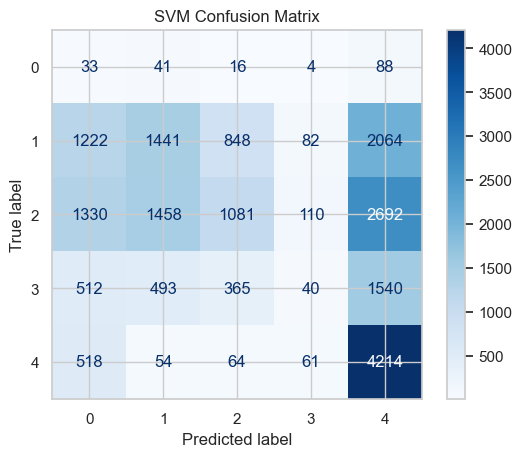

In [ ]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# draw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_m.classes_)
disp.plot(cmap=plt.cm.Blues)

# add title and graphic
plt.title('SVM Confusion Matrix')
plt.show()

## 5. Classification Report Comparison Before and After SMOTE

This section converts classification reports into DataFrames and compares precision, recall, and F1-score before and after SMOTE.


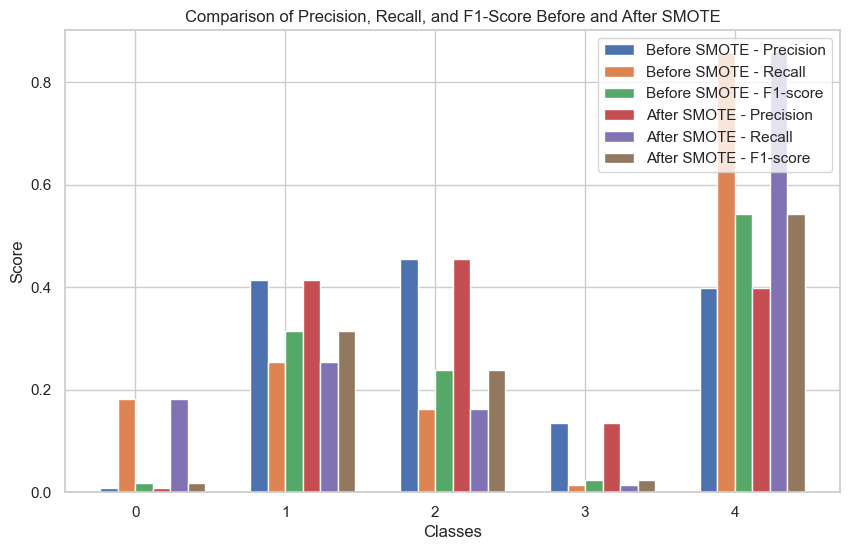

In [51]:
# transfer to dataframe
def get_classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return pd.DataFrame(report).transpose()

# get Report from before SMOTE or after SMOTE
report_no_smote = get_classification_report_df(y_test, y_pred)
report_smote = get_classification_report_df(y_test, y_pred_smote)

# draw precision, recall,f1 score compare diagram
metrics = ['precision', 'recall', 'f1-score']
labels = report_no_smote.index[:-3]  

x = np.arange(len(labels))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

# draw the diagram before SMOTE
for i, metric in enumerate(metrics):
    ax.bar(x - width/2 + i*width/3, report_no_smote[metric][:-3], width/3, label=f'Before SMOTE - {metric.capitalize()}')

# after SMOTE
for i, metric in enumerate(metrics):
    ax.bar(x + width/2 + i*width/3, report_smote[metric][:-3], width/3, label=f'After SMOTE - {metric.capitalize()}')

#draw the diagram
ax.set_xlabel('Classes')
ax.set_ylabel('Score')
ax.set_title('Comparison of Precision, Recall, and F1-Score Before and After SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')

plt.show()


## 6. Overall Metrics Comparison

This section compares overall evaluation metrics before and after SMOTE.


C:\Users\29084\AppData\Local\Temp\ipykernel_6368\1934624227.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  report_no_smote.loc['accuracy'][0],
C:\Users\29084\AppData\Local\Temp\ipykernel_6368\1934624227.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  report_smote.loc['accuracy'][0],


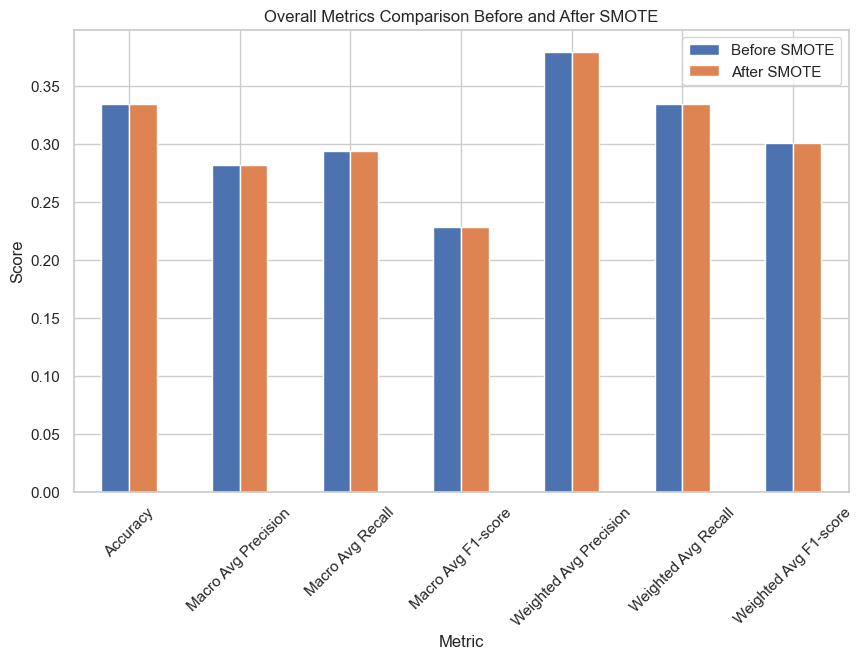

In [52]:
# compare
overall_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1-score', 'Weighted Avg Precision', 'Weighted Avg Recall', 'Weighted Avg F1-score'],
    'Before SMOTE': [
        report_no_smote.loc['accuracy'][0],
        report_no_smote.loc['macro avg']['precision'],
        report_no_smote.loc['macro avg']['recall'],
        report_no_smote.loc['macro avg']['f1-score'],
        report_no_smote.loc['weighted avg']['precision'],
        report_no_smote.loc['weighted avg']['recall'],
        report_no_smote.loc['weighted avg']['f1-score']
    ],
    'After SMOTE': [
        report_smote.loc['accuracy'][0],
        report_smote.loc['macro avg']['precision'],
        report_smote.loc['macro avg']['recall'],
        report_smote.loc['macro avg']['f1-score'],
        report_smote.loc['weighted avg']['precision'],
        report_smote.loc['weighted avg']['recall'],
        report_smote.loc['weighted avg']['f1-score']
    ]
})

# DRAW Diagram
overall_metrics.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.ylabel('Score')
plt.title('Overall Metrics Comparison Before and After SMOTE')
plt.xticks(rotation=45)
plt.show()


## 7. Additional SVM Confusion Matrix

This cell repeats the SVM confusion matrix visualisation from the original notebook.


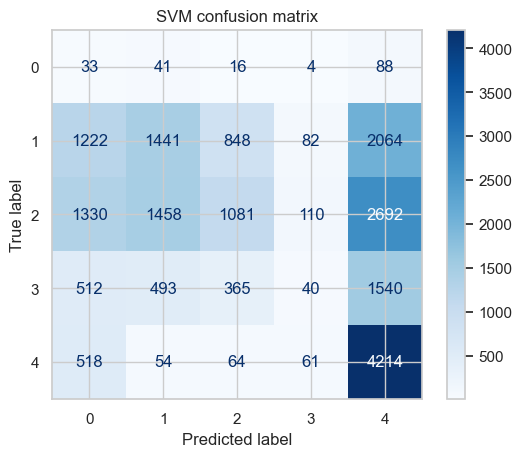

In [53]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_m.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title('SVM confusion matrix')
plt.show()

## Summary

This notebook preserves the original SVM experiments and evaluation visualisations.  
Further optimisation can be done later, but this version keeps the original content unchanged.
